<a href="https://colab.research.google.com/github/jarrodsb/ETAMU-binary-systems/blob/main/notebooks/RandomForestPrototype/Random_Forest_Prototype_Two_Planets.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Random Forest Classifier Toy Model for Classifying Planet Stability in Binary Systems (With Two Planets)

## Jarrod Bieber
## East Texas A&M University
## Summer 2026
---

## 1. Environment setup

In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as cm
import os

# Install scikit-learn
!pip install scikit-learn

# for importing training data from CSV
from google.colab import drive

# for data exploration
import seaborn as sns

# for building the models
from sklearn.model_selection import train_test_split
#from sklearn.preprocessing import LabelEncoder, StandardScaler # For scaling the numerical features -> (0 to 1)
from sklearn.ensemble import RandomForestClassifier

# for evaluating model performance
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, classification_report
#from mpl_toolkits.axes_grid1 import make_axes_locatable
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay

## Import Data
---

## 2. Import CSV file and convert into a pandas DataFrame

We import a CSV file containing thousands of simulations of a single-planet s-type binary system into our notebook. We convert our imported CSV with all of the extracted features and the determined stability labels into a pandas DataFrame. This DataFrame will be the input for training our machine-learning model.

In [2]:
drive.mount('/content/drive')

# Please replace 'your_filename.csv' with the actual name of your CSV file.
# Assuming the file is in the same directory as the notebook, the path might be:
# file_path = '/content/drive/MyDrive/your_filename.csv'
# If the file is in a subdirectory, adjust the path accordingly, e.g., '/content/drive/MyDrive/data/your_filename.csv'

# Example placeholder for the filename
csv_filename = "s_type_stability_data_two_planets_10000.csv" # Replace with your actual CSV file name

# Assuming the CSV file is in the same directory as the notebook, adjust the path as needed
file_path = f'/content/drive/MyDrive/East Texas A&M/ETAMU Research Assistant/Random Forest Prototype/{csv_filename}'

try:
    # Read the CSV file into a pandas DataFrame
    df = pd.read_csv(file_path)
    print(f"Successfully loaded '{csv_filename}' into DataFrame.")
    print("First 5 rows of the DataFrame:")
    display(df.head())
except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found. Please ensure the filename and path are correct and that Google Drive is mounted properly.")
except Exception as e:
    print(f"An error occurred while reading the CSV file: {e}")

Mounted at /content/drive
Successfully loaded 's_type_stability_data_two_planets_10000.csv' into DataFrame.
First 5 rows of the DataFrame:


,mu,e_bin,rho_crit_HW99_p1,rho_p1,e_p1,inc_p_deg_p1,megno_median_p1,megno_std_p1,e_p_free_p1,e_p_forced_p1,...,megno_std_p2,e_p_free_p2,e_p_forced_p2,a_p_std_p2,period_ratio_p2_p1,initial_separation_au,init_mutual_inc_deg,mmr_flag_2_1,mmr_flag_3_2,stable
0,0.368001,0.038669,0.302239,0.208149,0.050198,11.138208,47.747887,11.314050,1.022756,0.045469,...,11.314050,0.917353,0.069916,37.724752,18.66146,0.481290,163.555381,0,0,0
1,0.153644,0.281529,0.251224,0.149639,0.008077,32.987668,48.737497,10.312822,0.753210,0.043431,...,10.312822,0.773248,0.056066,11.280388,5.84471,0.191494,55.153262,0,0,0
2,0.848791,0.085616,0.100335,0.052354,0.033496,20.753183,261.766068,73.046352,2.225739,0.154698,...,73.046352,1.927567,0.256856,211.586097,NaN,0.125441,8.870851,0,0,0
3,0.692172,0.220636,0.097265,0.063379,0.165505,26.523702,54.561513,15.307143,2.317189,0.681143,...,15.307143,1.892038,0.194120,60.187560,NaN,0.227768,133.616801,0,0,0
4,0.311961,0.421096,0.139426,0.073906,0.093619,21.274844,53.746295,13.483088,1.891650,0.532686,...,13.483088,1.452210,0.147719,25.684779,NaN,0.193519,45.716268,0,0,0


### Features to be extracted for Two-Planet Systems:

**A. System-wide / Binary-driven Parameters (Common for both planets):**

1.  **`mu`**: The binary mass ratio, $m_B / (m_A + m_B)$. A fundamental system parameter describing the mass distribution within the binary.
2.  **`e_bin`**: The eccentricity of the binary orbit. Influences the strength and periodicity of gravitational perturbations on the planets.
3.  **`rho_crit_HW99_p1`**: The analytical critical semimajor axis ratio derived from Holman & Wiegert (1999), Table 1, for S-type planets. This is calculated using the binary's properties and serves as an empirical stability boundary for the inner planet.

**B. Planet-Specific Features (extracted for each planet, suffixed `_p1` for inner, `_p2` for outer):**

4.  **`rho`**: The ratio of the planetary semimajor axis to the binary semimajor axis, $a_p / a_{bin}$. Indicates how tightly the planet orbits within the binary system.
5.  **`e_p_free`**: The free eccentricity of the planet. Represents the component of eccentricity not forced by the binary's time-averaged gravitational field. It reflects the planet's intrinsic orbital shape.
6.  **`e_p_forced`**: The forced eccentricity amplitude of the planet. This is the eccentricity induced on the planet's orbit by the quasi-static gravitational field of the binary. It's calculated from the magnitude of the time-averaged eccentricity vector.
7.  **`inc_p_deg`**: The initial planetary inclination relative to the binary orbital plane (in degrees). High inclinations can lead to Kozai-Lidov cycles, potentially driving eccentricity variations.
8.  **`megno_median`**: The median value of the Mean Exponential Growth of Nearby Orbits (MEGNO) chaos indicator over the last 10% of the short integration. Values near 2 suggest regular motion, larger values indicate chaos.
9.  **`megno_std`**: The standard deviation of the MEGNO values over the last 80% of the integration. Characterizes the variability of the chaotic indicator, providing a robust measure by avoiding initial transients.
10. **`a_p_std`**: The standard deviation of the planetary semimajor axis over the short integration, normalized by its initial value. A proxy for orbital energy diffusion; larger values suggest less stable orbits and potential close encounters.

**C. Planet-Planet Interaction Features:**

11. **`period_ratio_p2_p1`**: The ratio of the initial orbital period of planet 2 to planet 1 ($P_2/P_1$). Values close to integer or half-integer ratios indicate potential mean-motion resonances.
12. **`initial_separation_au`**: The initial physical separation between planet 2 and planet 1, in astronomical units (since $a_{bin}=1$). ($a_{p2} - a_{p1}$).
13. **`init_mutual_inc_deg`**: The initial mutual inclination between the orbital planes of planet 1 and planet 2 (in degrees). This is the absolute difference in their inclinations assuming aligned nodes (since initial Omega is 0).
14. **`mmr_flag_2_1`**: A binary flag (1 if true, 0 if false) indicating if the initial period ratio `period_ratio_p2_p1` is approximately 2:1 (e.g., within 5% of 2.0). This signifies a potential 2:1 mean-motion resonance.
15. **`mmr_flag_3_2`**: A binary flag (1 if true, 0 if false) indicating if the initial period ratio `period_ratio_p2_p1` is approximately 3:2 (e.g., within 5% of 1.5). This signifies a potential 3:2 mean-motion resonance.

## 3. Data exploration

### Inspecting the DataFrame

In [3]:
print(f"Total stable systems: {df['stable'].sum()} out of {len(df)}")
print(f"Total unstable systems: {len(df) - df['stable'].sum()} out of {len(df)}")

Total stable systems: 5311 out of 10000
Total unstable systems: 4689 out of 10000


In [4]:
# Display the first few rows and a statistical summary of the DataFrame
print("DataFrame head:")
display(df.head())

print("\nDataFrame descriptive statistics:")
display(df.describe())

DataFrame head:


,mu,e_bin,rho_crit_HW99_p1,rho_p1,e_p1,inc_p_deg_p1,megno_median_p1,megno_std_p1,e_p_free_p1,e_p_forced_p1,...,megno_std_p2,e_p_free_p2,e_p_forced_p2,a_p_std_p2,period_ratio_p2_p1,initial_separation_au,init_mutual_inc_deg,mmr_flag_2_1,mmr_flag_3_2,stable
0,0.368001,0.038669,0.302239,0.208149,0.050198,11.138208,47.747887,11.314050,1.022756,0.045469,...,11.314050,0.917353,0.069916,37.724752,18.66146,0.481290,163.555381,0,0,0
1,0.153644,0.281529,0.251224,0.149639,0.008077,32.987668,48.737497,10.312822,0.753210,0.043431,...,10.312822,0.773248,0.056066,11.280388,5.84471,0.191494,55.153262,0,0,0
2,0.848791,0.085616,0.100335,0.052354,0.033496,20.753183,261.766068,73.046352,2.225739,0.154698,...,73.046352,1.927567,0.256856,211.586097,NaN,0.125441,8.870851,0,0,0
3,0.692172,0.220636,0.097265,0.063379,0.165505,26.523702,54.561513,15.307143,2.317189,0.681143,...,15.307143,1.892038,0.194120,60.187560,NaN,0.227768,133.616801,0,0,0
4,0.311961,0.421096,0.139426,0.073906,0.093619,21.274844,53.746295,13.483088,1.891650,0.532686,...,13.483088,1.452210,0.147719,25.684779,NaN,0.193519,45.716268,0,0,0



DataFrame descriptive statistics:


,mu,e_bin,rho_crit_HW99_p1,rho_p1,e_p1,inc_p_deg_p1,megno_median_p1,megno_std_p1,e_p_free_p1,e_p_forced_p1,...,megno_std_p2,e_p_free_p2,e_p_forced_p2,a_p_std_p2,period_ratio_p2_p1,initial_separation_au,init_mutual_inc_deg,mmr_flag_2_1,mmr_flag_3_2,stable
count,10000.000000,10000.000000,10000.000000,10000.000000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,...,10000.000000,10000.000000,10000.000000,10000.000000,3125.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,0.400414,0.262929,0.181877,0.088688,1.139598e-01,19.754984,57.116306,14.370224,1.801110,0.375269,...,14.370224,1.375769,0.219011,245.932857,137.230306,0.445004,60.732955,0.002300,0.003400,0.531100
std,0.205342,0.177695,0.080621,0.039573,8.734043e-02,11.534658,146.615120,39.705455,0.687672,0.379514,...,39.705455,0.534202,0.262502,2763.847628,4394.732777,0.358247,56.853944,0.047906,0.058213,0.499057
min,0.100015,0.000043,0.071443,0.050001,9.174569e-08,0.002430,0.810826,0.000031,0.405267,0.000423,...,0.000031,0.250925,0.000272,0.462034,0.000003,0.050268,0.000758,0.000000,0.000000,0.000000
25%,0.227498,0.112421,0.115282,0.059040,3.587595e-02,9.638326,2.662400,0.259425,1.226860,0.081885,...,0.259425,0.970488,0.041226,24.298821,0.192925,0.193386,11.095486,0.000000,0.000000,0.000000
50%,0.364148,0.236592,0.165029,0.075038,9.797384e-02,19.629844,14.736406,3.565399,1.760131,0.231353,...,3.565399,1.315137,0.105632,46.611895,0.844973,0.336158,34.544350,0.000000,0.000000,1.000000
75%,0.550672,0.391814,0.236112,0.106184,1.829844e-01,29.740050,48.529905,11.935318,2.304734,0.565132,...,11.935318,1.718755,0.297878,102.736381,4.491344,0.577841,116.190049,0.000000,0.000000,1.000000
max,0.899798,0.699909,0.422650,0.279267,2.999708e-01,39.995500,2743.418923,816.993455,4.058018,2.334430,...,816.993455,3.569168,1.907654,176340.132279,229961.278020,2.706485,179.884670,1.000000,1.000000,1.000000


### Class Balance

In [5]:
# Print the class balance of the 'stable' column
print("Stability class balance:")
display(df['stable'].value_counts())

Stability class balance:


,count
stable,
1,5311
0,4689


### Correlation Matrix Heatmap

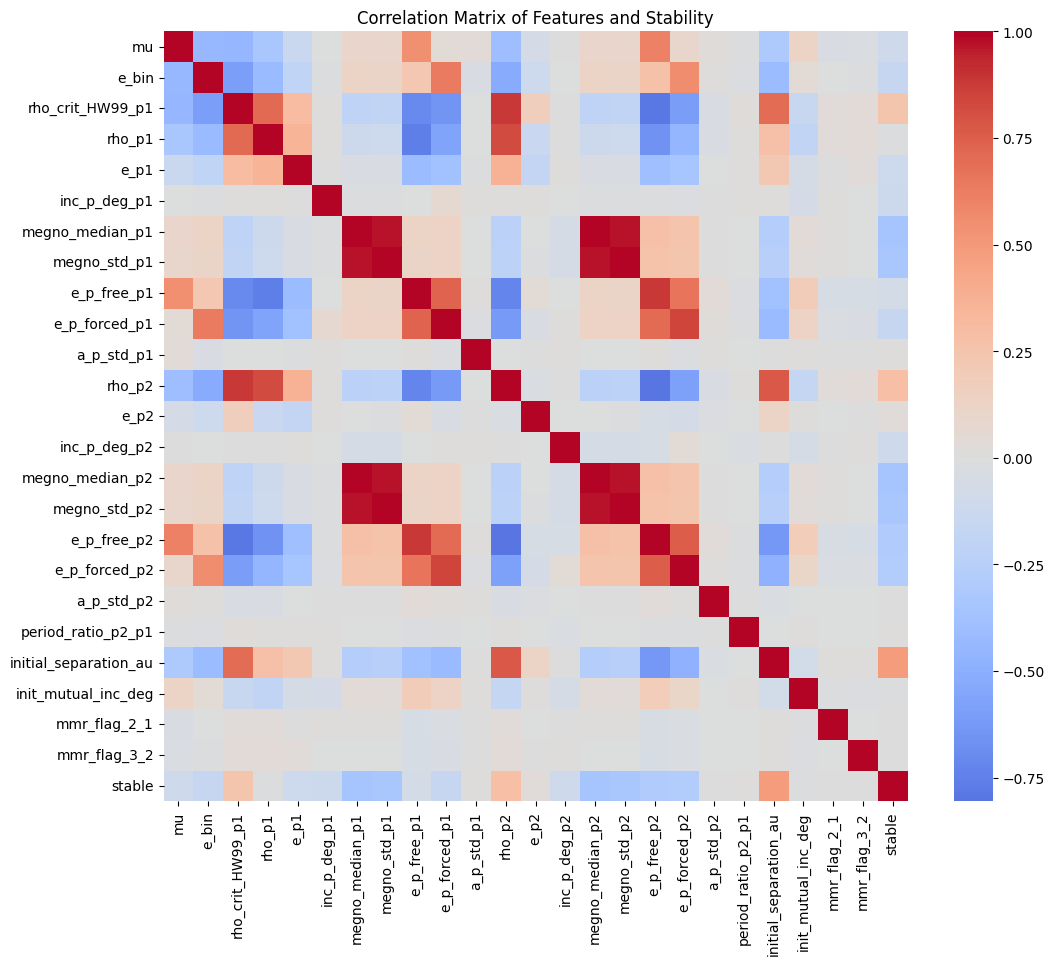

In [7]:
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(numeric_only=True), annot=False, cmap='coolwarm', fmt=".2f", center=0)
plt.title('Correlation Matrix of Features and Stability')
plt.show()

## 4. Building the Model
---

### Data Splitting

In [9]:
# Define features (X) and target (y)
# The feature_columns list should contain the names of the features we want to use for the ML model.
# We will use the 10 features, excluding 'rho_crit_HW99' from X directly
# as it's an analytical baseline we compare against, not a feature for the ML model itself.

feature_columns = [
    'mu', 'e_bin',
    'rho_p1', 'e_p_free_p1', 'e_p_forced_p1', 'inc_p_deg_p1', 'megno_median_p1', 'megno_std_p1', 'a_p_std_p1',
    'rho_p2', 'e_p_free_p2', 'e_p_forced_p2', 'inc_p_deg_p2', 'megno_median_p2', 'megno_std_p2', 'a_p_std_p2',
    'period_ratio_p2_p1', 'initial_separation_au', 'init_mutual_inc_deg', 'mmr_flag_2_1', 'mmr_flag_3_2'
]

X = df[feature_columns]
y = df['stable']

# Encode the target variable 'y' (Only needed to convert text labels into numbers)
#le = LabelEncoder()
#y_encoded = le.fit_transform(y)

# Split the data into training and testing sets


#X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

print("\ny_train class balance:")
display(pd.Series(y_train).value_counts())

print("\ny_test class balance:")
display(pd.Series(y_test).value_counts())

X_train shape: (8000, 21)
X_test shape: (2000, 21)
y_train shape: (8000,)
y_test shape: (2000,)

y_train class balance:


,count
stable,
1,4249
0,3751



y_test class balance:


,count
stable,
1,1062
0,938


### Training a RandomForestClassifier

In [10]:
# Initialize the Random Forest Classifier
# Using class_weight='balanced' can help mitigate the effects of class imbalance
# by adjusting weights inversely proportional to class frequencies. This is crucial given our imbalanced dataset.
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')

# Train the model
rf_model.fit(X_train, y_train)

print("RandomForestClassifier trained successfully.")

RandomForestClassifier trained successfully.


## 5. Evaluating Model Performance and Feature Importance
---

Accuracy: 0.8975
AUC: 0.9679

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.89      0.89       938
           1       0.90      0.90      0.90      1062

    accuracy                           0.90      2000
   macro avg       0.90      0.90      0.90      2000
weighted avg       0.90      0.90      0.90      2000


Confusion Matrix:


,Predicted Unstable,Predicted Stable
Actual Unstable,836,102
Actual Stable,103,959


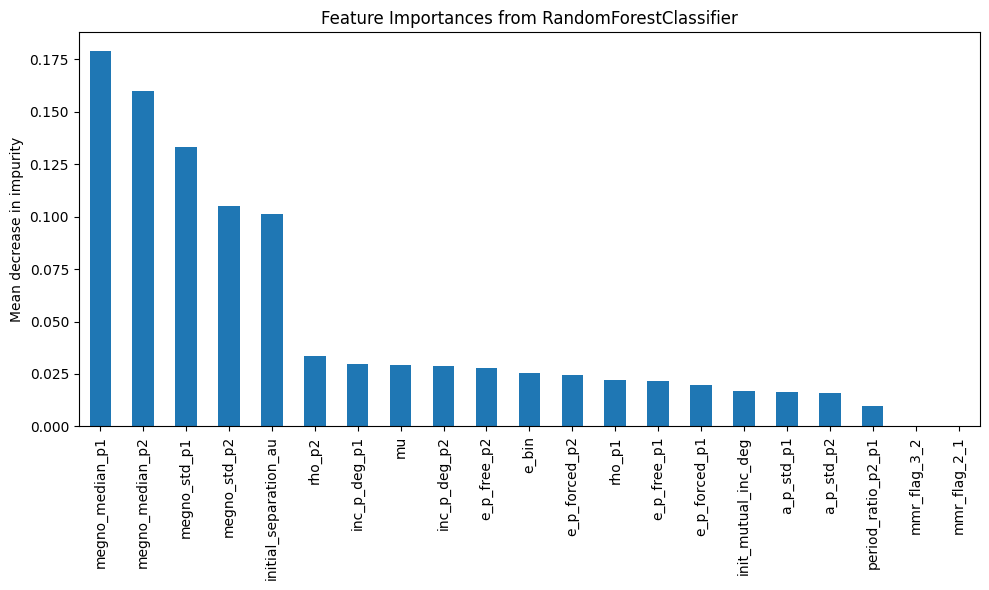

In [11]:
# Make predictions on the test set
y_pred = rf_model.predict(X_test)
y_pred_proba = rf_model.predict_proba(X_test)[:, 1] # Probability of the positive class (stable)

# Report Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

# Report AUC (Area Under the Receiver Operating Characteristic Curve)
# AUC calculation can fail if there's only one class present in y_true or y_score.
# We use a try-except block to handle this gracefully, which is likely given the small number of stable samples.
try:
    auc = roc_auc_score(y_test, y_pred_proba)
    print(f"AUC: {auc:.4f}")
except ValueError as e:
    print(f"Could not calculate AUC: {e}. This is often due to only one class being present in y_test or y_pred_proba for the test set.")
    auc = np.nan # Assign NaN if AUC cannot be calculated

print("\nClassification Report:")
# zero_division=0 to prevent warnings if a class has no predicted samples
print(classification_report(y_test, y_pred, zero_division=0))

print("\nConfusion Matrix:")
display(pd.DataFrame(confusion_matrix(y_test, y_pred), index=['Actual Unstable', 'Actual Stable'], columns=['Predicted Unstable', 'Predicted Stable']))

# Feature Importance Plot
importances = rf_model.feature_importances_
feature_names = X.columns

forest_importances = pd.Series(importances, index=feature_names)

fig, ax = plt.subplots(figsize=(10, 6))
forest_importances.sort_values(ascending=False).plot.bar(ax=ax)
ax.set_title("Feature Importances from RandomForestClassifier")
ax.set_ylabel("Mean decrease in impurity")
fig.tight_layout()
plt.show()

### Confusion Matrix

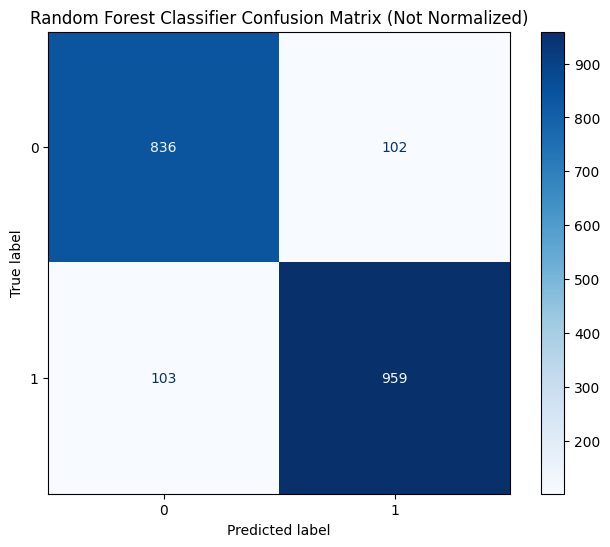

In [12]:
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap=plt.cm.Blues, ax=ax)
ax.set_title('Random Forest Classifier Confusion Matrix (Not Normalized)')
plt.show()

### ROC AUC Curve

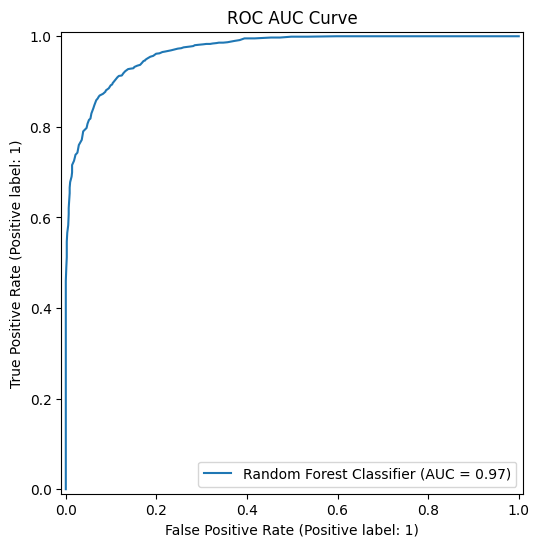

In [13]:
fig, ax = plt.subplots(figsize=(8, 6))
RocCurveDisplay.from_predictions(y_test, y_pred_proba, name='Random Forest Classifier', ax=ax)
ax.set_title('ROC AUC Curve')
plt.show()

### Precision-recall Curve


*   PR curves are more informative than ROC when the positive class is rare.
*   Average Precision (AP) ranges from 0.0 (worst) to 1.0 (perfect).
*   A score of 0.74 sits well above random guessing, showing that the model reliably ranks true positives higher than false positives.



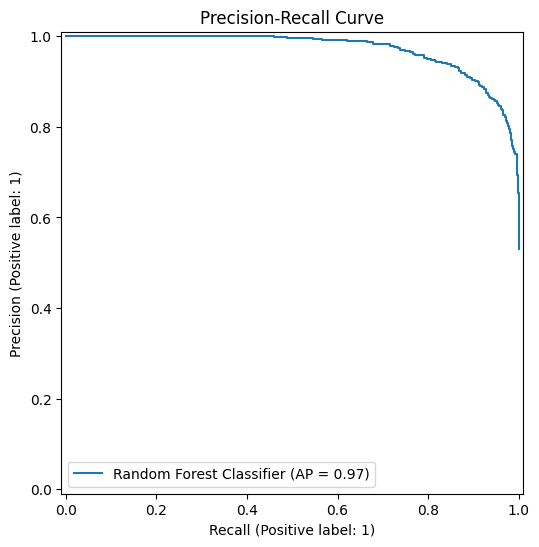

In [14]:
fig, ax = plt.subplots(figsize=(8, 6))
PrecisionRecallDisplay.from_predictions(y_test, y_pred_proba, name='Random Forest Classifier', ax=ax)
ax.set_title('Precision-Recall Curve')
plt.show()

### Comparison with `rho_crit_HW99` Analytic Baseline

In [15]:
# Predict stability based on rho_crit_HW99: stable if rho < rho_crit_HW99
# We need to ensure 'rho_crit_HW99' is available in the test set for comparison.
# X_test_analytic will be the subset of the original DataFrame corresponding to the test set indices.

# First, ensure 'rho_crit_HW99' is in the original df and then extract the test set portion.
# Since 'rho_crit_HW99' is calculated and added to the 'df' DataFrame, we can use df.loc[X_test.index]
# to get the corresponding rows from the original DataFrame.

X_test_full = df.loc[X_test.index]

# Calculate the predicted stability based on the analytic formula:
# If rho (planetary semimajor axis ratio) is less than rho_crit_HW99, it's considered stable (1), otherwise unstable (0).
y_pred_analytic = (X_test_full['rho_p1'] < X_test_full['rho_crit_HW99_p1']).astype(int)

# Evaluate the analytic baseline
accuracy_analytic = accuracy_score(y_test, y_pred_analytic)

# AUC for analytic baseline
try:
    auc_analytic = roc_auc_score(y_test, y_pred_analytic)
    print(f"Analytic Baseline AUC: {auc_analytic:.4f}")
except ValueError as e:
    print(f"Could not calculate Analytic Baseline AUC: {e}. This is often due to only one class being present in y_test.")
    auc_analytic = np.nan # Assign NaN if AUC cannot be calculated

print(f"Analytic Baseline Accuracy: {accuracy_analytic:.4f}")

print("\nAnalytic Baseline Classification Report:")
print(classification_report(y_test, y_pred_analytic, zero_division=0))

print("\nAnalytic Baseline Confusion Matrix:")
display(pd.DataFrame(confusion_matrix(y_test, y_pred_analytic), index=['Actual Unstable', 'Actual Stable'], columns=['Predicted Unstable', 'Predicted Stable']))

print("\nSummary Comparison:")
print(f"RandomForest Accuracy: {accuracy:.4f}")
print(f"Analytic Baseline Accuracy: {accuracy_analytic:.4f}")

rf_auc_str = f'{auc:.4f}' if not np.isnan(auc) else 'N/A'
analy_auc_str = f'{auc_analytic:.4f}' if not np.isnan(auc_analytic) else 'N/A'
print(f"RandomForest AUC: {rf_auc_str}")
print(f"Analytic Baseline AUC: {analy_auc_str}")


Analytic Baseline AUC: 0.5000
Analytic Baseline Accuracy: 0.5310

Analytic Baseline Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       938
           1       0.53      1.00      0.69      1062

    accuracy                           0.53      2000
   macro avg       0.27      0.50      0.35      2000
weighted avg       0.28      0.53      0.37      2000


Analytic Baseline Confusion Matrix:


,Predicted Unstable,Predicted Stable
Actual Unstable,0,938
Actual Stable,0,1062



Summary Comparison:
RandomForest Accuracy: 0.8975
Analytic Baseline Accuracy: 0.5310
RandomForest AUC: 0.9679
Analytic Baseline AUC: 0.5000
